# 01 — `demo_sig`: synthetic test signals

`scitex_dsp.demo_sig(...)` is the on-ramp for every other example.
It returns `(batch, channels, samples)` plus the time vector and
sampling rate.

Available `sig_type`s: `uniform`, `gauss`, `periodic`, `chirp`,
`ripple`, `meg`, `tensorpac`, `pac`. The optional ones (`meg`,
`ripple`, `tensorpac`) need extra dependencies.

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import scitex_dsp as dsp
%matplotlib inline

np.random.seed(0)
xx, tt, fs = dsp.demo_sig(sig_type="periodic", batch_size=2,
                          n_chs=4, t_sec=2, fs=512,
                          freqs_hz=[5, 12, 30])
print("shape:", xx.shape, "fs:", fs, "t in [", tt[0], ",", tt[-1], "]")

shape: (2, 4, 1024) fs: 512 t in [ 0.0 , 1.998046875 ]


## A gallery of signal types

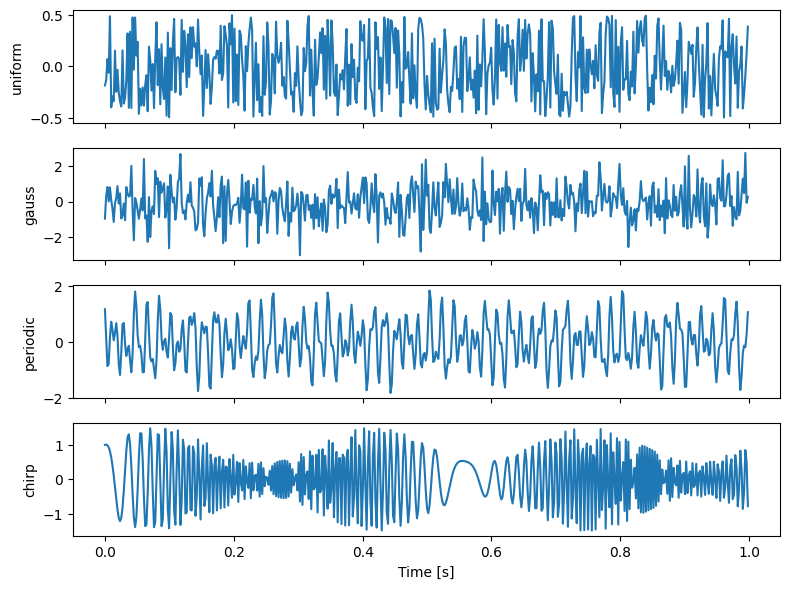

In [2]:
sig_types = ["uniform", "gauss", "periodic", "chirp"]
fig, axes = plt.subplots(len(sig_types), 1, figsize=(8, 6), sharex=True)
for ax, st in zip(axes, sig_types):
    xx, tt, fs = dsp.demo_sig(sig_type=st, batch_size=1, n_chs=1,
                              t_sec=1, fs=512)
    ax.plot(tt, xx[0, 0])
    ax.set_ylabel(st)
axes[-1].set_xlabel("Time [s]")
fig.tight_layout()
plt.show()


## Why `(batch, channels, samples)`?

Every `scitex_dsp` function expects this layout (or
`(channels, samples)` — see `ensure_3d` in the next notebook).
`batch` lets you process many trials at once; `channels` is the
multi-electrode axis.